# Hourly Citi Bike Demand Prediction with a Simple NumPy ANN

This notebook builds a simple Artificial Neural Network (ANN) from scratch to predict **hourly Citi Bike demand** in New York City.

- **Target variable:** `ride_count`
- **Problem type:** supervised regression
- **Libraries used:** **NumPy**, **Pandas**, and **Matplotlib** only
- **Modeling approach:** one-hidden-layer feedforward neural network implemented manually with backpropagation

The goal is to create a simple and readable ANN baseline for a course project, not a highly optimized production model.

In [ ]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1. Data Loading and Initial Inspection

The code below loads the cleaned hourly neighborhood-level Citi Bike dataset, checks the structure, previews the data, and parses `hour_slot` as a datetime column when available.

In [ ]:
df = pd.read_csv('datasets/hourly_neighborhood_2025.csv')

print(f'\nDataset shape: {df.shape}')
print('\nColumns:')
for column in df.columns:
    print(f' - {column}')

print('\nFirst 5 rows:')
display(df.head())

print('\nMissing values by column:')
display(df.isna().sum().sort_values(ascending=False).to_frame('missing_count'))

sort_column = None

if 'hour_slot' in df.columns:
    df['hour_slot'] = pd.to_datetime(df['hour_slot'], errors='coerce')
    if df['hour_slot'].notna().any():
        sort_column = 'hour_slot'
    else:
        warnings.warn("'hour_slot' exists but could not be parsed. Falling back to row order.")
else:
    warnings.warn("'hour_slot' is missing. Falling back to row order.")


Dataset shape: (569399, 15)

Columns:
 - hour_slot
 - NTA2020
 - NTAName
 - BoroName
 - ride_count
 - mean_duration_min
 - median_duration_min
 - member_count
 - casual_count
 - classic_count
 - electric_count
 - hour
 - dow
 - month
 - is_weekend

First 5 rows:


,hour_slot,NTA2020,NTAName,BoroName,ride_count,mean_duration_min,median_duration_min,member_count,casual_count,classic_count,electric_count,hour,dow,month,is_weekend
0,2025-01-01 00:00:00,BK0101,Greenpoint,Brooklyn,20,17.231,12.777,14.0,6.0,3.0,17.0,0,2,1,False
1,2025-01-01 00:00:00,BK0102,Williamsburg,Brooklyn,61,13.744,12.268,42.0,19.0,11.0,50.0,0,2,1,False
2,2025-01-01 00:00:00,BK0104,East Williamsburg,Brooklyn,25,12.735,10.587,18.0,7.0,4.0,21.0,0,2,1,False
3,2025-01-01 00:00:00,BK0201,Brooklyn Heights,Brooklyn,12,12.493,11.263,8.0,4.0,3.0,9.0,0,2,1,False
4,2025-01-01 00:00:00,BK0202,Downtown Brooklyn-DUMBO-Boerum Hill,Brooklyn,44,14.702,11.773,30.0,14.0,10.0,34.0,0,2,1,False



Missing values by column:


,missing_count
hour_slot,0
NTA2020,0
NTAName,0
BoroName,0
ride_count,0
mean_duration_min,0
median_duration_min,0
member_count,0
casual_count,0
classic_count,0


## 2. Feature Selection and Preprocessing

The notebook starts from the proposal feature set:

- Temporal inputs based on `hour`, `dow`, `month`, and `is_weekend`
- Spatial categorical inputs from `NTA2020` and `BoroName`
- Weather inputs if available

A small practical improvement is used for time variables: when `hour`, `dow`, or `month` are available, they are converted into simple **cyclical sine/cosine features**. This keeps the ANN simple while representing repeating calendar structure more naturally than raw integers alone.

In [ ]:
work_df = df.copy()

raw_temporal_candidates = ['hour', 'dow', 'month', 'is_weekend']
spatial_candidates = ['NTA2020', 'BoroName']
weather_numeric_candidates = ['temp', 'prcp', 'rhum', 'wspd', 'cldc']
weather_categorical_candidates = ['weather_condition']

available_temporal_raw = [col for col in raw_temporal_candidates if col in work_df.columns]
available_spatial = [col for col in spatial_candidates if col in work_df.columns]
available_weather_numeric = [col for col in weather_numeric_candidates if col in work_df.columns]
available_weather_categorical = [col for col in weather_categorical_candidates if col in work_df.columns]

if 'is_weekend' in work_df.columns:
    is_weekend_map = {
        'true': 1, 'false': 0,
        't': 1, 'f': 0,
        'yes': 1, 'no': 0,
        'y': 1, 'n': 0,
        '1': 1, '0': 0,
        'True': 1, 'False': 0,
        True: 1, False: 0,
    }
    work_df['is_weekend'] = work_df['is_weekend'].replace(is_weekend_map)

for col in available_temporal_raw + available_weather_numeric + [TARGET]:
    work_df[col] = pd.to_numeric(work_df[col], errors='coerce')

# Cyclical encodings help a simple ANN represent repeating time structure.
# Convert repeating time variables into sine/cosine pairs so the ANN treats
#boundary values as close together. For example, hour 23 and hour 0 are
# adjacent in real time, even though their raw numeric values are far apart.
engineered_temporal_features = []
if 'hour' in work_df.columns:
    work_df['hour_sin'] = np.sin(2 * np.pi * work_df['hour'] / 24)
    work_df['hour_cos'] = np.cos(2 * np.pi * work_df['hour'] / 24)
    engineered_temporal_features.extend(['hour_sin', 'hour_cos'])
if 'dow' in work_df.columns:
    work_df['dow_sin'] = np.sin(2 * np.pi * work_df['dow'] / 7)
    work_df['dow_cos'] = np.cos(2 * np.pi * work_df['dow'] / 7)
    engineered_temporal_features.extend(['dow_sin', 'dow_cos'])
if 'month' in work_df.columns:
    work_df['month_sin'] = np.sin(2 * np.pi * (work_df['month'] - 1) / 12)
    work_df['month_cos'] = np.cos(2 * np.pi * (work_df['month'] - 1) / 12)
    engineered_temporal_features.extend(['month_sin', 'month_cos'])

numeric_feature_columns = []
if 'is_weekend' in work_df.columns:
    numeric_feature_columns.append('is_weekend')
numeric_feature_columns.extend(engineered_temporal_features)
numeric_feature_columns.extend(available_weather_numeric)

categorical_columns = available_spatial + available_weather_categorical
encoded_categorical = pd.DataFrame(index=work_df.index)
if categorical_columns:
    encoded_categorical = pd.get_dummies(
        work_df[categorical_columns],
        prefix=categorical_columns,
        prefix_sep='=',
        dtype=float,
    )

numeric_features_df = work_df[numeric_feature_columns].astype(float).copy() if numeric_feature_columns else pd.DataFrame(index=work_df.index)
feature_matrix_df = pd.concat([numeric_features_df, encoded_categorical], axis=1)
all_feature_columns = feature_matrix_df.columns.tolist()
one_hot_columns = encoded_categorical.columns.tolist()

print('Features considered from the proposal:')
print(f' - Raw temporal columns found: {available_temporal_raw if available_temporal_raw else "None"}')
print(f' - Spatial categorical columns found: {available_spatial if available_spatial else "None"}')
print('\nFeatures actually used for modeling:')
print(f' - Numeric model features: {numeric_feature_columns if numeric_feature_columns else "None"}')
print(f' - One-hot encoded columns: {len(one_hot_columns)}')
print(f' - Total encoded input features: {len(all_feature_columns)}')

model_df = pd.concat([
    work_df[[sort_column]].copy() if sort_column is not None else pd.DataFrame(index=work_df.index),
    feature_matrix_df,
    work_df[[TARGET]].astype(float).copy(),
], axis=1)

required_columns = all_feature_columns + [TARGET]
rows_before_drop = len(model_df)
model_df = model_df.dropna(subset=required_columns).reset_index(drop=True)
rows_after_drop = len(model_df)

/var/folders/n0/l26t3ct16pb5p1jztl8x2x6m0000gn/T/ipykernel_1203/2832220011.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  work_df['is_weekend'] = work_df['is_weekend'].replace(is_weekend_map)


Features considered from the proposal:
 - Raw temporal columns found: ['hour', 'dow', 'month', 'is_weekend']
 - Spatial categorical columns found: ['NTA2020', 'BoroName']

Features actually used for modeling:
 - Numeric model features: ['is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
 - One-hot encoded columns: 76
 - Total encoded input features: 83


## 3. Chronological Train / Validation / Test Split

The split is chronological and time-aware:

- 70% train
- 15% validation
- 15% test

When `hour_slot` is available, the split is done by **unique hourly timestamps** rather than raw rows. This avoids splitting the same hour across different subsets.

In [ ]:
if sort_column is not None:
    model_df = model_df.sort_values(sort_column).reset_index(drop=True)
    unique_times = np.array(sorted(model_df[sort_column].dropna().unique()))

    train_time_end_idx = int(len(unique_times) * 0.70)
    val_time_end_idx = int(len(unique_times) * 0.85)

    train_cutoff = unique_times[train_time_end_idx - 1]
    val_cutoff = unique_times[val_time_end_idx - 1]

    train_df = model_df[model_df[sort_column] <= train_cutoff].copy()
    val_df = model_df[(model_df[sort_column] > train_cutoff) & (model_df[sort_column] <= val_cutoff)].copy()
    test_df = model_df[model_df[sort_column] > val_cutoff].copy()

    print(f"Data split chronologically using unique '{sort_column}' timestamps.")
    print(f' - Train range: {train_df[sort_column].min()} to {train_df[sort_column].max()}')
    print(f' - Validation range: {val_df[sort_column].min()} to {val_df[sort_column].max()}')
    print(f' - Test range: {test_df[sort_column].min()} to {test_df[sort_column].max()}')
else:
    warnings.warn('Chronological timestamp split was not possible; using existing row order instead.')
    n_total = len(model_df)
    train_end = int(n_total * 0.70)
    val_end = int(n_total * 0.85)
    train_df = model_df.iloc[:train_end].copy()
    val_df = model_df.iloc[train_end:val_end].copy()
    test_df = model_df.iloc[val_end:].copy()

split_sizes = {
    'train': len(train_df),
    'validation': len(val_df),
    'test': len(test_df),
    'total': len(model_df),
}

print('\nSplit sizes:')
for split_name, split_size in split_sizes.items():
    print(f' - {split_name}: {split_size:,}')

if min(split_sizes['train'], split_sizes['validation'], split_sizes['test']) == 0:
    raise ValueError('At least one split is empty. The dataset is too small after preprocessing.')

Data split chronologically using unique 'hour_slot' timestamps.
 - Train range: 2025-01-01 00:00:00 to 2025-09-13 11:00:00
 - Validation range: 2025-09-13 12:00:00 to 2025-11-07 05:00:00
 - Test range: 2025-11-07 06:00:00 to 2025-12-31 23:00:00

Split sizes:
 - train: 397,565
 - validation: 87,751
 - test: 84,083
 - total: 569,399


## 4. Feature Normalization

Only the numeric input columns are normalized, and the normalization statistics are computed **from the training split only**.

One-hot encoded columns are left unchanged.

For more stable ANN optimization, the target is also standardized **for training only** and converted back to the original `ride_count` scale for evaluation and plotting.

In [ ]:
def normalize_numeric_columns(frame, numeric_cols, means, stds):
    transformed = frame.copy()
    if numeric_cols:
        transformed[numeric_cols] = ((transformed[numeric_cols].astype(float) - means) / stds).astype(float)
    return transformed

normalization_means = train_df[numeric_feature_columns].mean() if numeric_feature_columns else pd.Series(dtype=float)
normalization_stds = train_df[numeric_feature_columns].std(ddof=0) if numeric_feature_columns else pd.Series(dtype=float)
normalization_stds = normalization_stds.replace(0, 1.0)

train_df_norm = normalize_numeric_columns(train_df, numeric_feature_columns, normalization_means, normalization_stds)
val_df_norm = normalize_numeric_columns(val_df, numeric_feature_columns, normalization_means, normalization_stds)
test_df_norm = normalize_numeric_columns(test_df, numeric_feature_columns, normalization_means, normalization_stds)

normalization_stats = pd.DataFrame({
    'mean_train_only': normalization_means,
    'std_train_only': normalization_stds,
})

print('Normalization statistics used for numeric features:')
display(normalization_stats)

X_train = train_df_norm[all_feature_columns].to_numpy(dtype=float)
X_val = val_df_norm[all_feature_columns].to_numpy(dtype=float)
X_test = test_df_norm[all_feature_columns].to_numpy(dtype=float)

y_train = train_df_norm[[TARGET]].to_numpy(dtype=float)
y_val = val_df_norm[[TARGET]].to_numpy(dtype=float)
y_test = test_df_norm[[TARGET]].to_numpy(dtype=float)

# A log transform makes the heavy right-skew in ride_count easier for a simple ANN to learn.
# In earlier runs without the log transform, the ANN tended to underpredict
# high-demand hours because a few very large ride_count values dominated the scale.
y_train_model = np.log1p(y_train)
y_val_model = np.log1p(y_val)
y_test_model = np.log1p(y_test)

target_mean = float(y_train_model.mean())
target_std = float(y_train_model.std())
if target_std == 0:
    target_std = 1.0

y_train_scaled = (y_train_model - target_mean) / target_std
y_val_scaled = (y_val_model - target_mean) / target_std
y_test_scaled = (y_test_model - target_mean) / target_std

print('Array shapes:')
print(f' - X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f' - X_val:   {X_val.shape}, y_val:   {y_val.shape}')
print(f' - X_test:  {X_test.shape}, y_test:  {y_test.shape}')
print(f' - Log-target scaling mean/std (train only): {target_mean:.4f}, {target_std:.4f}')

Normalization statistics used for numeric features:


,mean_train_only,std_train_only
is_weekend,0.283435,0.450666
hour_sin,-0.030088,0.708466
hour_cos,-0.039847,0.703977
dow_sin,0.001153,0.707133
dow_cos,-0.010816,0.706996
month_sin,0.332471,0.559850
month_cos,-0.161084,0.741676


Array shapes:
 - X_train: (397565, 83), y_train: (397565, 1)
 - X_val:   (87751, 83), y_val:   (87751, 1)
 - X_test:  (84083, 83), y_test:  (84083, 1)
 - Log-target scaling mean/std (train only): 3.3318, 1.5147


## 5. ANN From Scratch with NumPy

The network below is a simple feedforward ANN with:

- input layer
- one hidden layer
- ReLU activation
- one scalar output for regression

The implementation includes manual forward propagation, mean squared error (MSE), backpropagation, and gradient descent.

In [ ]:
def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)


def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def rmse(y_true, y_pred):
    return np.sqrt(mse_loss(y_true, y_pred))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1 - (ss_res / ss_tot)


class SimpleANNRegressor:
    def __init__(self, input_size, hidden_size=32, learning_rate=0.003, seed=42):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        rng = np.random.default_rng(seed)

        self.W1 = rng.normal(0, np.sqrt(2 / max(1, input_size)), size=(input_size, hidden_size))
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = rng.normal(0, np.sqrt(2 / max(1, hidden_size)), size=(hidden_size, 1))
        self.b2 = np.zeros((1, 1))

    def forward(self, X):
        Z1 = X @ self.W1 + self.b1
        A1 = relu(Z1)
        Z2 = A1 @ self.W2 + self.b2
        y_pred = Z2
        cache = {
            'X': X,
            'Z1': Z1,
            'A1': A1,
            'y_pred': y_pred,
        }
        return y_pred, cache

    def backward(self, y_true, cache):
        X = cache['X']
        Z1 = cache['Z1']
        A1 = cache['A1']
        y_pred = cache['y_pred']
        n_samples = len(X)

        d_y_pred = (2.0 / n_samples) * (y_pred - y_true)
        dW2 = A1.T @ d_y_pred
        db2 = np.sum(d_y_pred, axis=0, keepdims=True)

        dA1 = d_y_pred @ self.W2.T
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        gradients = {
            'dW1': dW1,
            'db1': db1,
            'dW2': dW2,
            'db2': db2,
        }
        return gradients

    def step(self, gradients):
        self.W1 -= self.learning_rate * gradients['dW1']
        self.b1 -= self.learning_rate * gradients['db1']
        self.W2 -= self.learning_rate * gradients['dW2']
        self.b2 -= self.learning_rate * gradients['db2']

    def train_batch(self, X_batch, y_batch):
        y_pred, cache = self.forward(X_batch)
        loss = mse_loss(y_batch, y_pred)
        gradients = self.backward(y_batch, cache)
        self.step(gradients)
        return loss

    def predict(self, X):
        y_pred, _ = self.forward(X)
        return y_pred

    def get_state(self):
        return {
            'W1': self.W1.copy(),
            'b1': self.b1.copy(),
            'W2': self.W2.copy(),
            'b2': self.b2.copy(),
        }

    def set_state(self, state):
        self.W1 = state['W1'].copy()
        self.b1 = state['b1'].copy()
        self.W2 = state['W2'].copy()
        self.b2 = state['b2'].copy()

## 6. Training Loop with Early Stopping

This section trains the model, monitors both training and validation loss, and uses early stopping to keep the best weights in memory.

In [ ]:
def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=80,
    patience=15,
    print_every=10,
    batch_size=4096,
    seed=42,
):
    rng = np.random.default_rng(seed)
    history = {
        'epoch': [],
        'train_loss': [],
        'val_loss': [],
    }

    best_state = model.get_state()
    best_val_loss = np.inf
    best_epoch = 0
    epochs_without_improvement = 0
    n_train = len(X_train)

    for epoch in range(1, epochs + 1):
        if batch_size is None or batch_size >= n_train:
            model.train_batch(X_train, y_train)
        else:
            permutation = rng.permutation(n_train)
            X_train_shuffled = X_train[permutation]
            y_train_shuffled = y_train[permutation]

            for start in range(0, n_train, batch_size):
                end = start + batch_size
                X_batch = X_train_shuffled[start:end]
                y_batch = y_train_shuffled[start:end]
                model.train_batch(X_batch, y_batch)

        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)
        train_loss = mse_loss(y_train, train_pred)
        val_loss = mse_loss(y_val, val_pred)

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if epoch == 1 or epoch % print_every == 0:
            print(f'Epoch {epoch:4d} | train_loss={train_loss:10.4f} | val_loss={val_loss:10.4f}')

        if val_loss < best_val_loss - 1e-8:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = model.get_state()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f'Early stopping triggered at epoch {epoch}. Best epoch: {best_epoch}')
            break

    model.set_state(best_state)
    return history, best_epoch, best_val_loss


HIDDEN_SIZE = 64
LEARNING_RATE = 0.003
EPOCHS = 200
PATIENCE = 15
PRINT_EVERY = 10
BATCH_SIZE = 4096
RANDOM_SEED = 42

model = SimpleANNRegressor(
    input_size=X_train.shape[1],
    hidden_size=HIDDEN_SIZE,
    learning_rate=LEARNING_RATE,
    seed=RANDOM_SEED,
)

history, best_epoch, best_val_loss = train_model(
    model=model,
    X_train=X_train,
    y_train=y_train_scaled,
    X_val=X_val,
    y_val=y_val_scaled,
    epochs=EPOCHS,
    patience=PATIENCE,
    print_every=PRINT_EVERY,
    batch_size=BATCH_SIZE,
    seed=RANDOM_SEED,
)

print(f'\nBest validation loss (scaled log-target MSE): {best_val_loss:.4f} at epoch {best_epoch}')

Epoch    1 | train_loss=    0.8711 | val_loss=    0.9621
Epoch   10 | train_loss=    0.6744 | val_loss=    0.7587
Epoch   20 | train_loss=    0.5820 | val_loss=    0.6703
Epoch   30 | train_loss=    0.4850 | val_loss=    0.5723
Epoch   40 | train_loss=    0.3829 | val_loss=    0.4675
Epoch   50 | train_loss=    0.2916 | val_loss=    0.3670
Epoch   60 | train_loss=    0.2256 | val_loss=    0.2909
Epoch   70 | train_loss=    0.1852 | val_loss=    0.2416
Epoch   80 | train_loss=    0.1619 | val_loss=    0.2124
Epoch   90 | train_loss=    0.1476 | val_loss=    0.1931
Epoch  100 | train_loss=    0.1382 | val_loss=    0.1813
Epoch  110 | train_loss=    0.1314 | val_loss=    0.1726
Epoch  120 | train_loss=    0.1264 | val_loss=    0.1668
Epoch  130 | train_loss=    0.1223 | val_loss=    0.1620
Epoch  140 | train_loss=    0.1190 | val_loss=    0.1579
Epoch  150 | train_loss=    0.1162 | val_loss=    0.1540
Epoch  160 | train_loss=    0.1139 | val_loss=    0.1503
Epoch  170 | train_loss=    0.1

## 7. Evaluation

The model is evaluated on the train, validation, and test splits using three regression metrics implemented from scratch with NumPy:

- MAE
- RMSE
- R²

All reported metrics are converted back to the original `ride_count` scale.

In [ ]:
def inverse_transform_target(y_scaled, mean, std):
    return np.expm1(y_scaled * std + mean)


def evaluate_split(model, X, y_true_original, target_mean, target_std):
    predictions_scaled = model.predict(X)
    predictions_original = inverse_transform_target(predictions_scaled, target_mean, target_std)
    return {
        'MAE': float(mae(y_true_original, predictions_original)),
        'RMSE': float(rmse(y_true_original, predictions_original)),
        'R2': float(r2_score(y_true_original, predictions_original)),
        'predictions': predictions_original,
    }

train_results = evaluate_split(model, X_train, y_train, target_mean, target_std)
val_results = evaluate_split(model, X_val, y_val, target_mean, target_std)
test_results = evaluate_split(model, X_test, y_test, target_mean, target_std)

metrics_table = pd.DataFrame({
    'train': {k: v for k, v in train_results.items() if k != 'predictions'},
    'validation': {k: v for k, v in val_results.items() if k != 'predictions'},
    'test': {k: v for k, v in test_results.items() if k != 'predictions'},
}).T

print('Model performance by split:')
display(metrics_table)

Model performance by split:


,MAE,RMSE,R2
train,22.116543,48.336058,0.817043
validation,32.141496,67.630998,0.755408
test,20.775219,42.832097,0.701344


## 8. Training Curves and Test Predictions

These plots help diagnose how the ANN trained and how closely the predictions match the actual test demand values.

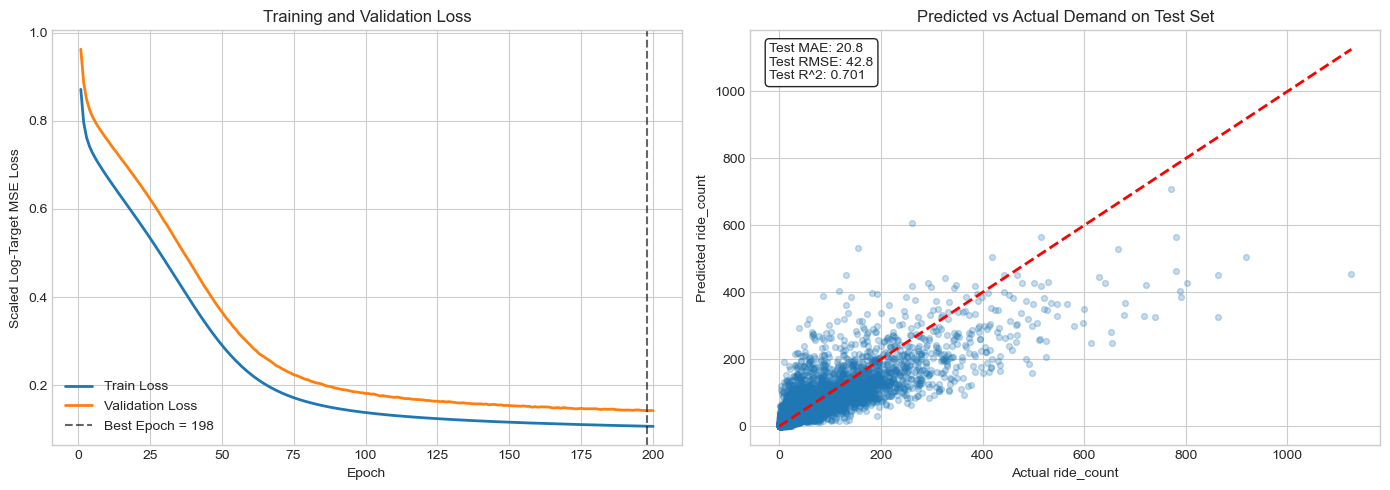

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['epoch'], history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['epoch'], history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].axvline(best_epoch, color='black', linestyle='--', alpha=0.6, label=f'Best Epoch = {best_epoch}')
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Scaled Log-Target MSE Loss')
axes[0].legend()

actual_test = y_test.ravel()
predicted_test = test_results['predictions'].ravel()

# Sample points so the saved scatter plot stays readable.
max_points = 10000
if len(actual_test) > max_points:
    sample_idx = np.random.default_rng(42).choice(len(actual_test), size=max_points, replace=False)
    actual_plot = actual_test[sample_idx]
    predicted_plot = predicted_test[sample_idx]
else:
    actual_plot = actual_test
    predicted_plot = predicted_test

axes[1].scatter(actual_plot, predicted_plot, alpha=0.25, s=18)
line_min = float(min(actual_plot.min(), predicted_plot.min()))
line_max = float(max(actual_plot.max(), predicted_plot.max()))
axes[1].plot([line_min, line_max], [line_min, line_max], color='red', linestyle='--', linewidth=2)
axes[1].set_title('Predicted vs Actual Demand on Test Set')
axes[1].set_xlabel('Actual ride_count')
axes[1].set_ylabel('Predicted ride_count')
axes[1].text(
    0.03,
    0.97,
    f"Test MAE: {test_results['MAE']:.1f}\nTest RMSE: {test_results['RMSE']:.1f}\nTest R^2: {test_results['R2']:.3f}",
    transform=axes[1].transAxes,
    va='top',
    bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.85},
)

plt.tight_layout()
plt.show()

## 9. Result Interpretation

The current outputs suggest that the ANN is learning meaningful structure in the hourly demand data.

- The training and validation loss curves both decrease steadily across the run, which suggests stable optimization rather than noisy or divergent training.
- The best validation result occurs near the end of training at about epoch 198, so increasing the training budget to 200 epochs was still useful for this model.
- The gap between training loss and validation loss is present but not extreme, which suggests some generalization error but not severe overfitting.
- In the predicted-vs-actual scatter plot, the points broadly follow the 45-degree reference line, so the model is capturing the overall demand pattern.
- The model still smooths very large demand spikes somewhat, but it tracks high-demand periods better than the earlier raw-target version.
- With a test R² of about 0.70, the ANN appears to be a strong simple baseline for this project.

## 10. Final Summary

This prints the target variable, the features used, split sizes, the hyperparameters used for the ANN, and the final train, validation, and test metrics from the current 200-epoch run.

In [ ]:
summary = {
    'target_variable': TARGET,
    'features_used': all_feature_columns,
    'numeric_features_normalized': numeric_feature_columns,
    'one_hot_features_not_normalized': one_hot_columns,
    'split_sizes': split_sizes,
    'best_hyperparameters_used': {
        'hidden_size': HIDDEN_SIZE,
        'learning_rate': LEARNING_RATE,
        'epochs_requested': EPOCHS,
        'patience': PATIENCE,
        'batch_size': BATCH_SIZE,
        'best_epoch': best_epoch,
    },
    'final_metrics': {
        'train': {'MAE': train_results['MAE'], 'RMSE': train_results['RMSE'], 'R2': train_results['R2']},
        'validation': {'MAE': val_results['MAE'], 'RMSE': val_results['RMSE'], 'R2': val_results['R2']},
        'test': {'MAE': test_results['MAE'], 'RMSE': test_results['RMSE'], 'R2': test_results['R2']},
    },
}

print('Final Project ANN Summary')
print('=' * 40)
print(f"Target variable: {summary['target_variable']}")
print(f"Total features used: {len(summary['features_used'])}")
print(f"Features used: {summary['features_used']}")
print(f"Split sizes: {summary['split_sizes']}")
print(f"Best hyperparameters used: {summary['best_hyperparameters_used']}")
print('Train metrics: ' + f"MAE={train_results['MAE']:.4f}, RMSE={train_results['RMSE']:.4f}, R2={train_results['R2']:.4f}")
print('Validation metrics: ' + f"MAE={val_results['MAE']:.4f}, RMSE={val_results['RMSE']:.4f}, R2={val_results['R2']:.4f}")
print('Test metrics: ' + f"MAE={test_results['MAE']:.4f}, RMSE={test_results['RMSE']:.4f}, R2={test_results['R2']:.4f}")

Final Project ANN Summary
Target variable: ride_count
Total features used: 83
Features used: ['is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'NTA2020=BK0101', 'NTA2020=BK0102', 'NTA2020=BK0103', 'NTA2020=BK0104', 'NTA2020=BK0201', 'NTA2020=BK0202', 'NTA2020=BK0203', 'NTA2020=BK0204', 'NTA2020=BK0261', 'NTA2020=BK0301', 'NTA2020=BK0302', 'NTA2020=BK0401', 'NTA2020=BK0402', 'NTA2020=BK0601', 'NTA2020=BK0602', 'NTA2020=BK0701', 'NTA2020=BK0702', 'NTA2020=BK0703', 'NTA2020=BK0771', 'NTA2020=BK0801', 'NTA2020=BK0802', 'NTA2020=BK0891', 'NTA2020=BK0901', 'NTA2020=BK0902', 'NTA2020=BK1001', 'NTA2020=BK1201', 'NTA2020=BK1202', 'NTA2020=BK1203', 'NTA2020=BK1401', 'NTA2020=BK1402', 'NTA2020=BK1601', 'NTA2020=BK1602', 'NTA2020=BK1701', 'NTA2020=BK1702', 'NTA2020=BK1703', 'NTA2020=BK1771', 'NTA2020=BK5591', 'NTA2020=MN0101', 'NTA2020=MN0102', 'NTA2020=MN0191', 'NTA2020=MN0201', 'NTA2020=MN0202', 'NTA2020=MN0203', 'NTA2020=MN0301', 'NTA2020=MN0302', 'NTA2020=M

## 12. Final Markdown Summary

- **What was changed:** the final notebook uses a unique-timestamp chronological split, safer numeric normalization, cyclical encodings for `hour`, `dow`, and `month`, a `log1p(ride_count)` target transform, and a slightly larger hidden layer to improve peak-demand prediction while keeping the ANN simple.
- **Hyperparameters used:** hidden layer size = 64, learning rate = 0.003, epochs = 200, patience = 15, batch size = 4096.
- **What the loss curves show:** both training and validation loss decrease smoothly throughout the run, and the best validation result appears near epoch 198, which indicates stable learning and no obvious training failure.
- **What the scatter plot shows:** predicted demand follows the overall upward pattern in actual demand and aligns reasonably well with the 45-degree reference line, although very large demand spikes are still somewhat smoothed.
- **Final train metrics:** MAE = 22.1165, RMSE = 48.3361, R² = 0.8170.
- **Final validation metrics:** MAE = 32.1415, RMSE = 67.6310, R² = 0.7554.
- **Final test metrics:** MAE = 20.7752, RMSE = 42.8321, R² = 0.7013.
- **Overall judgment:** this is still a simple one-hidden-layer NumPy ANN, but the current ANN is a stronger and credible baseline for the Citi Bike Demand Prediction
